In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/diabetes_binary_health_indicators_BRFSS2015.csv
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/__results__.html
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/diabetes_012_health_indicators_BRFSS2015.csv
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/__resultx__.html
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/__notebook__.ipynb
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/__output__.json
/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/custom.css


## Task 2: Creating the Notebook and Loading Data

In [2]:
data = pd.read_csv('/kaggle/input/notebooks/alexteboul/diabetes-health-indicators-dataset-notebook/diabetes_012_health_indicators_BRFSS2015.csv')
diabetes = pd.DataFrame(data)
print(diabetes.head())

   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0   
1     

## Task 3: A Histogram For Age Distributions

<function matplotlib.pyplot.show(close=None, block=None)>

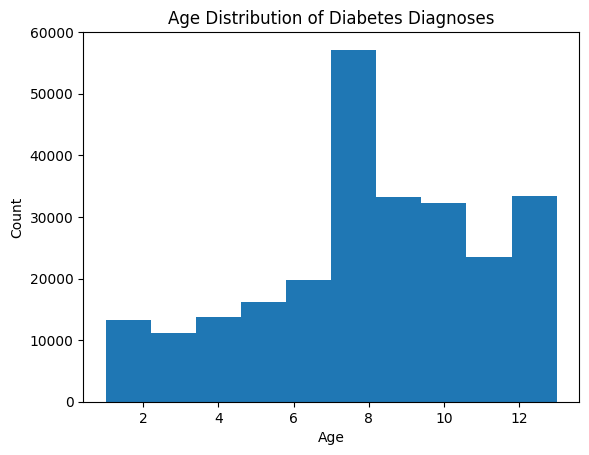

In [3]:
import matplotlib.pyplot as plt

plt.hist(data['Age'])
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution of Diabetes Diagnoses')
plt.show

## Task 4: General Health over Time

<function matplotlib.pyplot.show(close=None, block=None)>

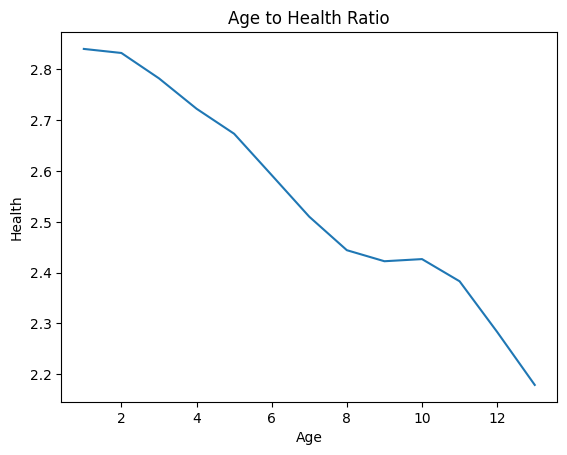

In [4]:
health_by_age = diabetes.groupby('Age').agg({'GenHlth' : 'mean'})
health_by_age['Health'] = 5 - health_by_age['GenHlth']
health_by_age.sort_index()

plt.plot(health_by_age['Health'])
plt.xlabel('Age')
plt.ylabel('Health')
plt.title('Age to Health Ratio')
plt.show

## Task 5: A Heat Map of All Columns

<function matplotlib.pyplot.show(close=None, block=None)>

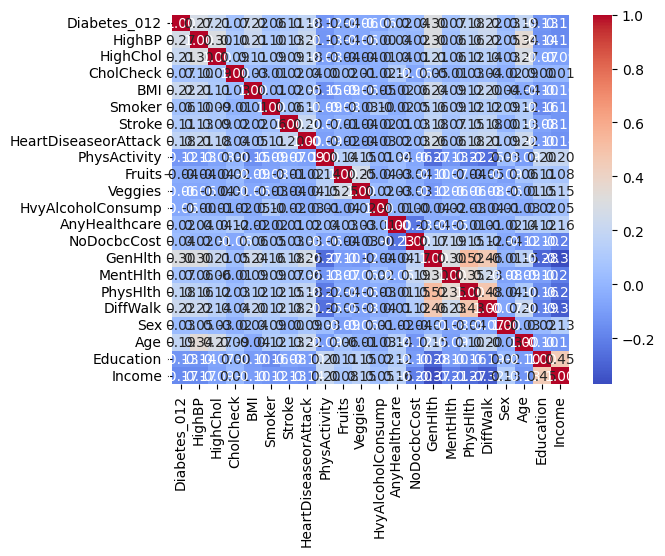

In [5]:
import seaborn as sns

diabetes_corr = diabetes.corr()
sns.heatmap(diabetes_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show


## Task 6: Subset Heat Maps

<function matplotlib.pyplot.show(close=None, block=None)>

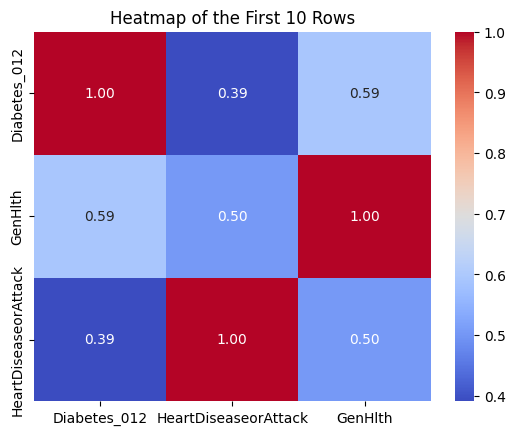

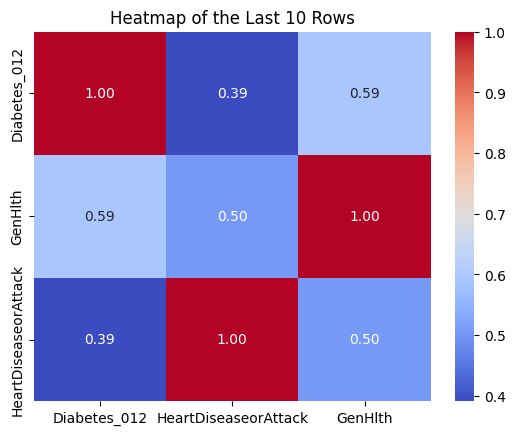

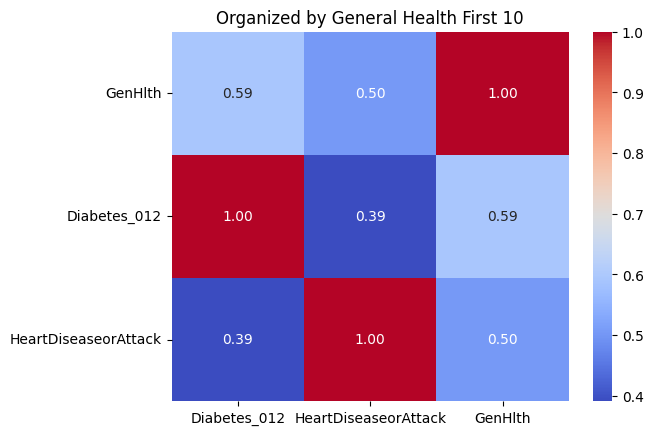

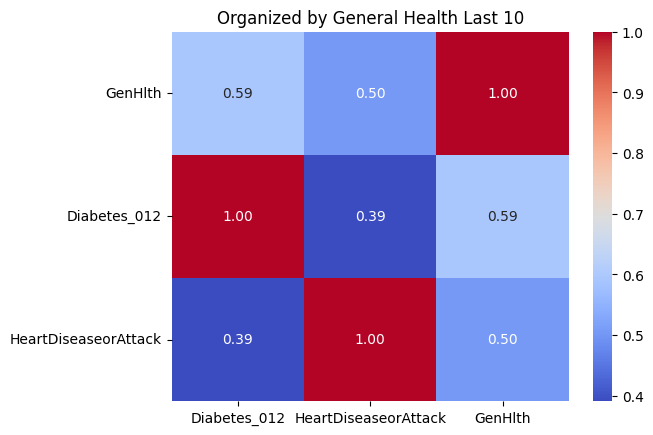

In [6]:
subset_cols = ['Diabetes_012', 'HeartDiseaseorAttack', 'GenHlth']
subset_df = diabetes_corr[subset_cols]
diabetes_corr_subset = subset_df.corr()
diabetes_corr_subset = diabetes_corr_subset.sort_values(by = 'Diabetes_012', ascending = False)

plt.figure(1)
sns.heatmap(diabetes_corr_subset.head(10), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap of the First 10 Rows")
plt.show

plt.figure(2)
sns.heatmap(diabetes_corr_subset.tail(10), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap of the Last 10 Rows")
plt.show

diabetes_corr_subset = diabetes_corr_subset.sort_values(by = 'GenHlth', ascending = False)

plt.figure(3)
sns.heatmap(diabetes_corr_subset.head(10), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Organized by General Health First 10')
plt.show

plt.figure(4)
sns.heatmap(diabetes_corr_subset.tail(10), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Organized by General Health Last 10')
plt.show


## Task 7: A Pair Plot: Body Mass Index vs. Age

/tmp/ipykernel_16/3827374709.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<function matplotlib.pyplot.show(close=None, block=None)>

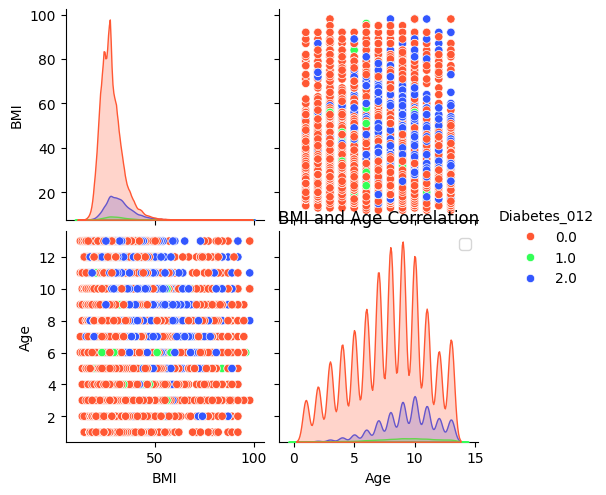

In [7]:
sns.pairplot(diabetes, vars=['BMI', 'Age'], hue = 'Diabetes_012', palette=['#FF5733', '#33FF57', '#3357FF'])
plt.title('BMI and Age Correlation')
plt.legend()
plt.show